# Censored Outcomes — Bone Marrow Transplant Case Study

This notebook demonstrates heterogeneous treatment effect (HTE) estimation with censored outcomes
on a real dataset from the Center for International Blood and Marrow Transplant Research (CIBMTR).

## Clinical Background

Allogeneic hematopoietic cell transplantation (HCT) is a therapy for acute myeloid leukemia (AML)
and myelodysplastic syndromes (MDS). Before transplantation, the host receives a conditioning
regimen to eliminate hematopoietic stem cells. Conventional myeloablative conditioning (MAC) can
be toxic, so reduced intensity conditioning (RIC) is sometimes used as an alternative.

- **MAC (control, A=0)**: `strataf` in {1, 2}  
- **RIC (treatment, A=1)**: `strataf` in {3, 4}

RIC may reduce non-relapse mortality (NRM, competing risk) but be less effective at preventing
relapse. We study three causal quantities at **τ = 4 years**:

1. **Relapse — total effect** (RMTL, competing risks)
2. **Relapse — separable direct & indirect effects** (RMTL, competing risks)
3. **Mortality (NRM)** — single-cause (RMST)
4. **Composite** relapse/mortality (RMST, single-cause framing)

## Data Availability

The dataset (`lk1602public.sas7bdat`) is **publicly available** through CIBMTR's research data
program. It was previously published by Bejanyan et al. (2021) *Myeloablative versus Reduced-
Intensity Conditioning with Matched-Unrelated Donors for Myeloid Malignancies* and is available
for secondary analysis at:

> **CIBMTR data portal**: https://cibmtr.org/Manuscript/a020h00001F1sihAAB/P-5370

Access requires registration and agreement to CIBMTR's Terms of Use for Publicly Available
Research Datasets. This analysis uses de-identified data; institutional review board approval
was not required.

## Python Implementations Used

| R (original) | Python (this notebook) |
|---|---|
| `two_learner` | `CompetingRisksTLearner`, `SurvivalTLearner`, `TLearner` |
| `iptw_learner` | `IPTWLearner` |
| `ra_learner` | `RALearner` |
| `u_learner` | `ULearner` |
| `aipcw_cut_rmtlj` | `aipcw_cut_rmtlj` |
| `aipcw_cut_rmtlj_sep_direct_astar1` | `aipcw_cut_rmtlj_sep_direct_astar1` |
| `aipcw_cut_rmst` | `aipcw_cut_rmst` |
| `survSuperLearner` | default `RandomSurvivalForest` |
| `SuperLearner` (propensity/outcome) | default `RandomForestClassifier` / `RandomForestRegressor` |

## Section 1: Dataset & Setup

In [1]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


from econml.metalearners._censor_metalearners import (
    SurvivalTLearner,
    SurvivalSLearner,
    CompetingRisksTLearner,
    CompetingRisksSLearner,
    SeparableDirectAstar1TLearner,
    SeparableIndirectAstar1TLearner,
    SeparableDirectAstar1SLearner,
    SeparableIndirectAstar1SLearner,
    TLearner,
    SLearner,
    XLearner,
    IPTWLearner,
    AIPTWLearner,
    MCLearner,
    MCEALearner,
    ULearner,
    RALearner,
    RLearner,
    IFLearner,
)
import econml.grf._causal_survival_forest as _causal_survival_forest
_causal_survival_forest = importlib.reload(_causal_survival_forest)
CausalSurvivalForest = _causal_survival_forest.CausalSurvivalForest
from econml.grf import GRFCausalForest as CausalForest
from econml.censor import (
    fit_nuisance_survival,
    ipcw_cut_rmst, bj_cut_rmst, aipcw_cut_rmst,
    ipcw_cut_rmtlj, bj_cut_rmtlj, aipcw_cut_rmtlj,
    aipcw_cut_rmtlj_sep_direct_astar1, aipcw_cut_rmtlj_sep_indirect_astar1,
    uif_diff_rmst,
    uif_diff_rmtlj, uif_diff_rmtlj_sep_direct_astar1, uif_diff_rmtlj_sep_indirect_astar1,
)


In [2]:
# Load SAS dataset
df = pd.read_sas('lk1602public.sas7bdat')
print(f'Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns')

tau = 4 * 365.25  # 1461 days
clip_hte = lambda y: np.clip(np.asarray(y, dtype=float).ravel(), -2 * tau, 2 * tau)

# Treatment: MAC (strataf in {1,2}) → A=0; RIC (strataf in {3,4}) → A=1
df['A'] = df['strataf'].isin([3, 4]).astype(float)

# Risk level covariate: strataf in {1,3} → low/intermediate; {2,4} → high/very high
df['risk_level'] = df['strataf'].isin([2, 4]).astype(float)

# Filter missing / coded-missing values
df = df[df['drsex'] != 99]
df = df[df['atggrp'] != 99]
df = df[df['kps'] != 99]

# Confounder list (14 variables)
cat_confounders = ['drsex', 'disease', 'distatus', 'amstatprgp', 'kps', 'wbcdxgp', 'atggrp',
                   'gvhdgpf', 'drcmvprf', 'donorgp_final', 'agegpff', 'graftype', 'risk_level']
confounders = ['yeartx'] + cat_confounders

df = df.reset_index(drop=True)
n = len(df)
print(f'After filtering: n = {n:,}')
print(f'Treatment balance: A=0 (MAC): {(df.A==0).sum():,}, A=1 (RIC): {(df.A==1).sum():,}')

Raw dataset: 4,387 rows, 25 columns
After filtering: n = 4,284
Treatment balance: A=0 (MAC): 2,597, A=1 (RIC): 1,687


In [3]:
# Build design matrix X (encode categoricals as dummies, drop first for identifiability)
X_df = pd.get_dummies(df[confounders].astype(float), drop_first=True)
X = X_df.values.astype(float)
T = df['A'].values

print(f'Feature matrix X: {X.shape}')

# -------------------------------------------------------------------
# Competing risks outcome (relapse as cause 1, NRM as cause 2)
#   time  = min(time-to-relapse, time-to-death) × 30.4167 days/month
#   event = 0 censored, 1 relapse, 2 NRM
# -------------------------------------------------------------------
time_competing = np.round(np.fmin(df['intxrel'].fillna(df['intxsurv']), df['intxsurv']) * 30.4167).astype(float)
rel_event = df['rel'].fillna(0).values.astype(float)
trm_event = df['trm'].fillna(0).values.astype(float)
event_competing = (rel_event + 2 * trm_event).astype(float)  # 0/1/2

# Mortality outcome (single cause)
time_mortality = np.round(df['intxsurv'] * 30.4167).astype(float)
event_mortality = trm_event.copy()

# Composite relapse-or-mortality outcome (single cause framing)
time_composite = time_competing.copy()  # same time as competing risks
event_composite = np.clip(rel_event + trm_event, 0, 1).astype(float)

print(f'Competing events — censored: {(event_competing==0).sum()}, relapse: {(event_competing==1).sum()}, NRM: {(event_competing==2).sum()}')
print(f'Mortality events — censored: {(event_mortality==0).sum()}, NRM: {(event_mortality==1).sum()}')
print(f'Composite events — censored: {(event_composite==0).sum()}, event: {(event_composite==1).sum()}')
print(f'tau = {tau:.1f} days ({tau/365.25:.0f} years)')

Feature matrix X: (4284, 14)
Competing events — censored: 1439, relapse: 1778, NRM: 1067
Mortality events — censored: 3217, NRM: 1067
Composite events — censored: 1439, event: 2845
tau = 1461.0 days (4 years)


## Section 2: Shared Nuisance Estimation (Competing Risks)

We fit censoring, event, cause-specific, and competing event survival models once and reuse them
across Sections 3 and 4. The notebook relies on the package defaults: `RandomSurvivalForest` for censored nuisance functions and direct survival learners, and random forests for binary and continuous pseudo-outcome learners.

In [4]:
print('Fitting nuisance models for competing risks...')
nuis = fit_nuisance_survival(
    time_competing, event_competing, T, X,
    cause=1,
    cv=2,
)
tg = nuis.time_grid
print(f'Done. Time grid: {len(tg)} points, range [{tg.min():.0f}, {tg.max():.0f}] days')


Fitting nuisance models for competing risks...
Done. Time grid: 1493 points, range [1, 3285] days


## Section 3: Relapse — Total Effect (Competing Risks RMTL)

Maps to `relapse_total_hte.R`. The estimand is the Restricted Mean Time Lost (RMTL) for cause 1
(relapse) at τ = 4 years.

Three pseudo-outcome transforms are available:
- **IPCW** (`Y_ipcw_total`): singly robust, requires correct censoring model
- **BJ** (`Y_bj_total`): singly robust, requires correct event model  
- **AIPCW** (`Y_aipcw_total`): doubly robust — used for learners below

All six transforms from Sections 3–4 (`Y_ipcw_total`, `Y_bj_total`, `Y_bj_sep_direct_astar1`,
`Y_bj_sep_indirect_astar1`, `Y_aipcw_sep_direct_astar1`, `Y_aipcw_sep_indirect_astar1`) can
replace `Y_aipcw_total` as the input to learners, depending on the quantity of interest.

In [5]:
# IPCW CUT (singly robust, censoring model)
Y_ipcw_total = ipcw_cut_rmtlj(
    T, time_competing, event_competing, tau,
    nuis.G_a0, nuis.G_a1,
    time_grid=tg,
)

# BJ CUT (singly robust, event model)
Y_bj_total = bj_cut_rmtlj(
    T, time_competing, event_competing, tau,
    nuis.S_a0, nuis.S_a1,
    nuis.Sj_a0, nuis.Sj_a1,
    time_grid=tg,
)

# AIPCW CUT (doubly robust) — primary pseudo-outcome for learners
Y_aipcw_total = aipcw_cut_rmtlj(
    T, time_competing, event_competing, tau,
    nuis.G_a0, nuis.G_a1,
    nuis.S_a0, nuis.S_a1,
    nuis.Sj_a0, nuis.Sj_a1,
    time_grid=tg,
)

print(f'Y_ipcw_total:  mean={Y_ipcw_total.mean():.2f}, std={Y_ipcw_total.std():.2f}, finite={np.isfinite(Y_ipcw_total).all()}')
print(f'Y_bj_total:    mean={Y_bj_total.mean():.2f}, std={Y_bj_total.std():.2f}, finite={np.isfinite(Y_bj_total).all()}')
print(f'Y_aipcw_total: mean={Y_aipcw_total.mean():.2f}, std={Y_aipcw_total.std():.2f}, finite={np.isfinite(Y_aipcw_total).all()}')

Y_ipcw_total:  mean=494.81, std=623.85, finite=True
Y_bj_total:    mean=494.48, std=617.65, finite=True
Y_aipcw_total: mean=494.80, std=622.87, finite=True


In [6]:
results_total = {}

# Direct competing-risk outcome object
competing_obj = np.array(
    [(int(e), t) for e, t in zip(event_competing, time_competing)],
    dtype=[('event', int), ('time', float)],
)

cr_slearner = CompetingRisksSLearner(
    tau=tau,
    cv=2,
)
cr_slearner.fit(competing_obj, T, X=X)
results_total['CompetingRisksSLearner'] = clip_hte(cr_slearner.effect(X))

cr_tlearner = CompetingRisksTLearner(
    tau=tau,
    cv=2,
)
cr_tlearner.fit(competing_obj, T, X=X)
results_total['CompetingRisksTLearner'] = clip_hte(cr_tlearner.effect(X))

tl = TLearner(cv=2)
tl.fit(Y_aipcw_total, T, X=X)
results_total['AIPCW + TLearner'] = clip_hte(tl.effect(X))

sl = SLearner(cv=2)
sl.fit(Y_aipcw_total, T, X=X)
results_total['AIPCW + SLearner'] = clip_hte(sl.effect(X))

cf = CausalForest(num_trees=200, seed=0)
cf.fit(X, Y_aipcw_total, T)
results_total['AIPCW + CausalForest'] = clip_hte(cf.effect(X))

ps = nuis.ps
bw = nuis.iptw
tilt = nuis.naive
Y_uif_diff_total = uif_diff_rmtlj(
    T, time_competing, event_competing, tau,
    bw, tilt,
    nuis.G_a0, nuis.G_a1,
    nuis.S_a0, nuis.S_a1,
    nuis.Sj_a0, nuis.Sj_a1,
    cause=1, time_grid=tg,
)
if_total = IFLearner(cv=2)
if_total.fit(Y_uif_diff_total, X=X)
results_total['IFLearner (total)'] = clip_hte(if_total.effect(X))

xl = XLearner(cv=2)
xl.fit(Y_aipcw_total, T, X=X)
results_total['AIPCW + XLearner'] = clip_hte(xl.effect(X))

aiptw = AIPTWLearner(cv=2)
aiptw.fit(Y_aipcw_total, T, X=X)
results_total['AIPCW + AIPTWLearner'] = clip_hte(aiptw.effect(X))

r_est = RLearner(cv=2)
r_est.fit(Y_aipcw_total, T, X=X)
results_total['AIPCW + RLearner'] = clip_hte(r_est.effect(X))

iptw = IPTWLearner(cv=2)
iptw.fit(Y_aipcw_total, T, X=X)
results_total['AIPCW + IPTWLearner'] = clip_hte(iptw.effect(X))

mc = MCLearner(cv=2)
mc.fit(Y_aipcw_total, T, X=X)
results_total['AIPCW + MCLearner'] = clip_hte(mc.effect(X))

mcea = MCEALearner(cv=2)
mcea.fit(Y_aipcw_total, T, X=X)
results_total['AIPCW + MCEALearner'] = clip_hte(mcea.effect(X))

u = ULearner(cv=2)
u.fit(Y_aipcw_total, T, X=X)
results_total['AIPCW + ULearner'] = clip_hte(u.effect(X))

ra = RALearner(cv=2)
ra.fit(Y_aipcw_total, T, X=X)
results_total['AIPCW + RALearner'] = clip_hte(ra.effect(X))

print('Relapse total effect ATEs (positive = RIC increases RMTL for relapse = harmful):')
for name, cate in results_total.items():
    print(f'  {name:35s}: ATE = {cate.mean():.4f}')


Relapse total effect ATEs (positive = RIC increases RMTL for relapse = harmful):
  CompetingRisksSLearner             : ATE = 154.0064
  CompetingRisksTLearner             : ATE = 151.8714
  AIPCW + TLearner                   : ATE = 145.4610
  AIPCW + SLearner                   : ATE = 153.6940
  AIPCW + CausalForest               : ATE = 170.4133
  IFLearner (total)                  : ATE = 277.5239
  AIPCW + XLearner                   : ATE = 159.8414
  AIPCW + AIPTWLearner               : ATE = 165.4247
  AIPCW + RLearner                   : ATE = 153.2400
  AIPCW + IPTWLearner                : ATE = 178.7623
  AIPCW + MCLearner                  : ATE = 16.7619
  AIPCW + MCEALearner                : ATE = 149.0004
  AIPCW + ULearner                   : ATE = 130.2736
  AIPCW + RALearner                  : ATE = 146.9260


## Section 4: Relapse — Separable Direct & Indirect Effects

Maps to `relapse_separable_direct_astar1_hte.R` and `relapse_separable_indirect_astar1_hte.R`.

The separable direct effect isolates RIC's pathway through stem cell elimination (relapse-specific),
while the indirect effect captures the pathway through NRM reduction.

**Note**: IPCW CUT is **not available** for separable effects — the censoring weighting cannot
be factored along the cause-specific pathway. Available transforms:
- **BJ separable** (`Y_bj_sep_direct_astar1`, `Y_bj_sep_indirect_astar1`): G=1 (no censoring
  correction), singly robust via event model
- **AIPCW separable** (`Y_aipcw_sep_direct_astar1`, `Y_aipcw_sep_indirect_astar1`): doubly robust

All variants are drop-in replacements for `Y_aipcw_total`, depending on the quantity of interest.
Learners below use the AIPCW variants.

In [7]:
# AIPCW separable direct effect (A=1 pathway via relapse mechanism)
Y_aipcw_sep_direct_astar1 = aipcw_cut_rmtlj_sep_direct_astar1(
    T, time_competing, event_competing, tau,
    nuis.G_a0, nuis.G_a1,
    nuis.S_a0, nuis.S_a1,
    nuis.Sj_a0, nuis.Sj_a1,
    nuis.Sjbar_a0, nuis.Sjbar_a1,
    time_grid=tg,
)

# AIPCW separable indirect effect (A=1 pathway via NRM mechanism)
Y_aipcw_sep_indirect_astar1 = aipcw_cut_rmtlj_sep_indirect_astar1(
    T, time_competing, event_competing, tau,
    nuis.G_a0, nuis.G_a1,
    nuis.S_a0, nuis.S_a1,
    nuis.Sj_a0, nuis.Sj_a1,
    nuis.Sjbar_a0, nuis.Sjbar_a1,
    time_grid=tg,
)

# BJ separable variants (G=1, no censoring correction, singly robust via event model)
n_times = len(tg)
G_ones_a0 = np.ones((n, n_times))
G_ones_a1 = np.ones((n, n_times))

Y_bj_sep_direct_astar1 = aipcw_cut_rmtlj_sep_direct_astar1(
    T, time_competing, event_competing, tau,
    G_ones_a0, G_ones_a1,
    nuis.S_a0, nuis.S_a1,
    nuis.Sj_a0, nuis.Sj_a1,
    nuis.Sjbar_a0, nuis.Sjbar_a1,
    time_grid=tg,
)

Y_bj_sep_indirect_astar1 = aipcw_cut_rmtlj_sep_indirect_astar1(
    T, time_competing, event_competing, tau,
    G_ones_a0, G_ones_a1,
    nuis.S_a0, nuis.S_a1,
    nuis.Sj_a0, nuis.Sj_a1,
    nuis.Sjbar_a0, nuis.Sjbar_a1,
    time_grid=tg,
)

print('Pseudo-outcome means (should: direct + indirect ≈ total):')
print(f'  Y_aipcw_total               = {Y_aipcw_total.mean():.4f}')
print(f'  Y_aipcw_sep_direct_astar1   = {Y_aipcw_sep_direct_astar1.mean():.4f}')
print(f'  Y_aipcw_sep_indirect_astar1 = {Y_aipcw_sep_indirect_astar1.mean():.4f}')
print(f'  direct + indirect           = {Y_aipcw_sep_direct_astar1.mean() + Y_aipcw_sep_indirect_astar1.mean():.4f}')
print(f'  Y_bj_sep_direct_astar1      = {Y_bj_sep_direct_astar1.mean():.4f}  (drop-in BJ)')
print(f'  Y_bj_sep_indirect_astar1    = {Y_bj_sep_indirect_astar1.mean():.4f}  (drop-in BJ)')

Pseudo-outcome means (should: direct + indirect ≈ total):
  Y_aipcw_total               = 494.8028
  Y_aipcw_sep_direct_astar1   = 552.7793
  Y_aipcw_sep_indirect_astar1 = 436.5527
  direct + indirect           = 989.3319
  Y_bj_sep_direct_astar1      = 551.8686  (drop-in BJ)
  Y_bj_sep_indirect_astar1    = 437.5177  (drop-in BJ)


In [8]:
results_sep = {}

# Direct competing-risk learners with separable-effect support
cr_s_sep_direct = SeparableDirectAstar1SLearner(
    tau=tau,
    cv=2,
)
cr_s_sep_direct.fit(competing_obj, T, X=X)
direct_cr_s = clip_hte(cr_s_sep_direct.effect(X))
results_sep['Direct: SeparableDirectAstar1SLearner'] = direct_cr_s

cr_s_sep_indirect = SeparableIndirectAstar1SLearner(
    tau=tau,
    cv=2,
)
cr_s_sep_indirect.fit(competing_obj, T, X=X)
indirect_cr_s = clip_hte(cr_s_sep_indirect.effect(X))
results_sep['Indirect: SeparableIndirectAstar1SLearner'] = indirect_cr_s

cr_t_sep_direct = SeparableDirectAstar1TLearner(
    tau=tau,
    cv=2,
)
cr_t_sep_direct.fit(competing_obj, T, X=X)
direct_cr_t = clip_hte(cr_t_sep_direct.effect(X))
results_sep['Direct: SeparableDirectAstar1TLearner'] = direct_cr_t

cr_t_sep_indirect = SeparableIndirectAstar1TLearner(
    tau=tau,
    cv=2,
)
cr_t_sep_indirect.fit(competing_obj, T, X=X)
indirect_cr_t = clip_hte(cr_t_sep_indirect.effect(X))
results_sep['Indirect: SeparableIndirectAstar1TLearner'] = indirect_cr_t

# UIF separable pseudo-outcomes
ps = nuis.ps
bw = nuis.iptw
tilt = nuis.naive
Y_uif_diff_sep_direct_astar1 = uif_diff_rmtlj_sep_direct_astar1(
    T, ps, time_competing, event_competing, tau,
    bw, tilt,
    nuis.G_a0, nuis.G_a1,
    nuis.S_a0, nuis.S_a1,
    nuis.Sj_a0, nuis.Sj_a1,
    nuis.Sjbar_a0, nuis.Sjbar_a1,
    cause=1, time_grid=tg,
)
Y_uif_diff_sep_indirect_astar1 = uif_diff_rmtlj_sep_indirect_astar1(
    T, ps, time_competing, event_competing, tau,
    bw, tilt,
    nuis.G_a0, nuis.G_a1,
    nuis.S_a0, nuis.S_a1,
    nuis.Sj_a0, nuis.Sj_a1,
    nuis.Sjbar_a0, nuis.Sjbar_a1,
    cause=1, time_grid=tg,
)

# --- Direct effect learners ---
tl_direct = TLearner(cv=2)
tl_direct.fit(Y_aipcw_sep_direct_astar1, T, X=X)
results_sep['Direct: AIPCW + TLearner'] = clip_hte(tl_direct.effect(X))

sl_direct = SLearner(cv=2)
sl_direct.fit(Y_aipcw_sep_direct_astar1, T, X=X)
results_sep['Direct: AIPCW + SLearner'] = clip_hte(sl_direct.effect(X))

cf_direct = CausalForest(num_trees=200, seed=0)
cf_direct.fit(X, Y_aipcw_sep_direct_astar1, T)
results_sep['Direct: AIPCW + CausalForest'] = clip_hte(cf_direct.effect(X))

if_direct = IFLearner(cv=2)
if_direct.fit(Y_uif_diff_sep_direct_astar1, X=X)
results_sep['Direct: IFLearner'] = clip_hte(if_direct.effect(X))

x_direct = XLearner(cv=2)
x_direct.fit(Y_aipcw_sep_direct_astar1, T, X=X)
results_sep['Direct: AIPCW + XLearner'] = clip_hte(x_direct.effect(X))

aiptw_direct = AIPTWLearner(cv=2)
aiptw_direct.fit(Y_aipcw_sep_direct_astar1, T, X=X)
results_sep['Direct: AIPCW + AIPTWLearner'] = clip_hte(aiptw_direct.effect(X))

r_direct = RLearner(cv=2)
r_direct.fit(Y_aipcw_sep_direct_astar1, T, X=X)
results_sep['Direct: AIPCW + RLearner'] = clip_hte(r_direct.effect(X))

iptw_direct = IPTWLearner(cv=2)
iptw_direct.fit(Y_aipcw_sep_direct_astar1, T, X=X)
results_sep['Direct: AIPCW + IPTWLearner'] = clip_hte(iptw_direct.effect(X))

mc_direct = MCLearner(cv=2)
mc_direct.fit(Y_aipcw_sep_direct_astar1, T, X=X)
results_sep['Direct: AIPCW + MCLearner'] = clip_hte(mc_direct.effect(X))

mcea_direct = MCEALearner(cv=2)
mcea_direct.fit(Y_aipcw_sep_direct_astar1, T, X=X)
results_sep['Direct: AIPCW + MCEALearner'] = clip_hte(mcea_direct.effect(X))

u_direct = ULearner(cv=2)
u_direct.fit(Y_aipcw_sep_direct_astar1, T, X=X)
results_sep['Direct: AIPCW + ULearner'] = clip_hte(u_direct.effect(X))

ra_direct = RALearner(cv=2)
ra_direct.fit(Y_aipcw_sep_direct_astar1, T, X=X)
results_sep['Direct: AIPCW + RALearner'] = clip_hte(ra_direct.effect(X))

# --- Indirect effect learners ---
tl_indirect = TLearner(cv=2)
tl_indirect.fit(Y_aipcw_sep_indirect_astar1, T, X=X)
results_sep['Indirect: AIPCW + TLearner'] = clip_hte(tl_indirect.effect(X))

sl_indirect = SLearner(cv=2)
sl_indirect.fit(Y_aipcw_sep_indirect_astar1, T, X=X)
results_sep['Indirect: AIPCW + SLearner'] = clip_hte(sl_indirect.effect(X))

cf_indirect = CausalForest(num_trees=200, seed=0)
cf_indirect.fit(X, Y_aipcw_sep_indirect_astar1, T)
results_sep['Indirect: AIPCW + CausalForest'] = clip_hte(cf_indirect.effect(X))

if_indirect = IFLearner(cv=2)
if_indirect.fit(Y_uif_diff_sep_indirect_astar1, X=X)
results_sep['Indirect: IFLearner'] = clip_hte(if_indirect.effect(X))

x_indirect = XLearner(cv=2)
x_indirect.fit(Y_aipcw_sep_indirect_astar1, T, X=X)
results_sep['Indirect: AIPCW + XLearner'] = clip_hte(x_indirect.effect(X))

aiptw_indirect = AIPTWLearner(cv=2)
aiptw_indirect.fit(Y_aipcw_sep_indirect_astar1, T, X=X)
results_sep['Indirect: AIPCW + AIPTWLearner'] = clip_hte(aiptw_indirect.effect(X))

r_indirect = RLearner(cv=2)
r_indirect.fit(Y_aipcw_sep_indirect_astar1, T, X=X)
results_sep['Indirect: AIPCW + RLearner'] = clip_hte(r_indirect.effect(X))

iptw_indirect = IPTWLearner(cv=2)
iptw_indirect.fit(Y_aipcw_sep_indirect_astar1, T, X=X)
results_sep['Indirect: AIPCW + IPTWLearner'] = clip_hte(iptw_indirect.effect(X))

mc_indirect = MCLearner(cv=2)
mc_indirect.fit(Y_aipcw_sep_indirect_astar1, T, X=X)
results_sep['Indirect: AIPCW + MCLearner'] = clip_hte(mc_indirect.effect(X))

mcea_indirect = MCEALearner(cv=2)
mcea_indirect.fit(Y_aipcw_sep_indirect_astar1, T, X=X)
results_sep['Indirect: AIPCW + MCEALearner'] = clip_hte(mcea_indirect.effect(X))

u_indirect = ULearner(cv=2)
u_indirect.fit(Y_aipcw_sep_indirect_astar1, T, X=X)
results_sep['Indirect: AIPCW + ULearner'] = clip_hte(u_indirect.effect(X))

ra_indirect = RALearner(cv=2)
ra_indirect.fit(Y_aipcw_sep_indirect_astar1, T, X=X)
results_sep['Indirect: AIPCW + RALearner'] = clip_hte(ra_indirect.effect(X))

print('Separable effect ATEs:')
for name, cate in results_sep.items():
    print(f'  {name:40s}: ATE = {cate.mean():.4f}')


Separable effect ATEs:
  Direct: SeparableDirectAstar1SLearner   : ATE = 138.6149
  Indirect: SeparableIndirectAstar1SLearner: ATE = 13.7198
  Direct: SeparableDirectAstar1TLearner   : ATE = 139.0223
  Indirect: SeparableIndirectAstar1TLearner: ATE = 14.7058
  Direct: AIPCW + TLearner                : ATE = 198.6847
  Direct: AIPCW + SLearner                : ATE = 194.5839
  Direct: AIPCW + CausalForest            : ATE = 169.0818
  Direct: IFLearner                       : ATE = 199.5983
  Direct: AIPCW + XLearner                : ATE = 208.0650
  Direct: AIPCW + AIPTWLearner            : ATE = 173.9401
  Direct: AIPCW + RLearner                : ATE = 218.0484
  Direct: AIPCW + IPTWLearner             : ATE = 234.5559
  Direct: AIPCW + MCLearner               : ATE = 95.6978
  Direct: AIPCW + MCEALearner             : ATE = 178.5350
  Direct: AIPCW + ULearner                : ATE = 162.5887
  Direct: AIPCW + RALearner               : ATE = 214.4284
  Indirect: AIPCW + TLearner      

## Section 5: Mortality — Single-Cause RMST

Maps to `mortality_hte.R`. The outcome is non-relapse mortality (NRM), modeled as a single-cause
survival problem (no competing risks).

In [9]:
print('Fitting nuisance models for mortality (single cause)...')
nuis_mort = fit_nuisance_survival(
    time_mortality, event_mortality, T, X,
    cv=2,
)
tg_mort = nuis_mort.time_grid
print(f'Done. Time grid: {len(tg_mort)} points')

# IPCW CUT (drop-in, singly robust)
Y_ipcw_mortality = ipcw_cut_rmst(
    T, time_mortality, event_mortality, tau,
    nuis_mort.G_a0, nuis_mort.G_a1,
    time_grid=tg_mort,
)

# BJ CUT (drop-in, singly robust)
Y_bj_mortality = bj_cut_rmst(
    T, time_mortality, event_mortality, tau,
    nuis_mort.S_a0, nuis_mort.S_a1,
    time_grid=tg_mort,
)

# AIPCW CUT (doubly robust) — primary
Y_aipcw_mortality = aipcw_cut_rmst(
    T, time_mortality, event_mortality, tau,
    nuis_mort.G_a0, nuis_mort.G_a1,
    nuis_mort.S_a0, nuis_mort.S_a1,
    time_grid=tg_mort,
)

print(f'Y_ipcw_mortality:  mean={Y_ipcw_mortality.mean():.2f}')
print(f'Y_bj_mortality:    mean={Y_bj_mortality.mean():.2f}')
print(f'Y_aipcw_mortality: mean={Y_aipcw_mortality.mean():.2f}')


Fitting nuisance models for mortality (single cause)...
Done. Time grid: 1661 points
Y_ipcw_mortality:  mean=1028.86
Y_bj_mortality:    mean=1141.15
Y_aipcw_mortality: mean=1119.80


In [10]:
results_mort = {}

# Direct survival-object input for single-cause mortality
surv_obj = np.array(
    [(bool(e), t) for e, t in zip(event_mortality, time_mortality)],
    dtype=[('event', bool), ('time', float)],
)

sv_slearner = SurvivalSLearner(
    tau=tau,
    cv=2,
)
sv_slearner.fit(surv_obj, T, X=X)
results_mort['SurvivalSLearner'] = clip_hte(sv_slearner.effect(X))

sv_tlearner = SurvivalTLearner(
    tau=tau,
    cv=2,
)
sv_tlearner.fit(surv_obj, T, X=X)
results_mort['SurvivalTLearner'] = clip_hte(sv_tlearner.effect(X))

csf_mort = CausalSurvivalForest(tau=tau, n_estimators=200, nuisance_cv=2, random_state=0)
csf_mort.fit(X, T, time_mortality, event_mortality.astype(bool))
results_mort['CausalSurvivalForest'] = clip_hte(csf_mort.effect(X))

tl_mort = TLearner(cv=2)
tl_mort.fit(Y_aipcw_mortality, T, X=X)
results_mort['AIPCW + TLearner'] = clip_hte(tl_mort.effect(X))

sl_mort = SLearner(cv=2)
sl_mort.fit(Y_aipcw_mortality, T, X=X)
results_mort['AIPCW + SLearner'] = clip_hte(sl_mort.effect(X))

cf_mort = CausalForest(num_trees=200, seed=0)
cf_mort.fit(X, Y_aipcw_mortality, T)
results_mort['AIPCW + CausalForest'] = clip_hte(cf_mort.effect(X))

bw_mort = nuis_mort.iptw
tilt_mort = nuis_mort.naive
Y_uif_diff_mortality = uif_diff_rmst(
    T, time_mortality, event_mortality, tau,
    bw_mort, tilt_mort,
    nuis_mort.G_a0, nuis_mort.G_a1,
    nuis_mort.S_a0, nuis_mort.S_a1,
    time_grid=tg_mort,
)
if_mort = IFLearner(cv=2)
if_mort.fit(Y_uif_diff_mortality, X=X)
results_mort['IFLearner'] = clip_hte(if_mort.effect(X))

xl_mort = XLearner(cv=2)
xl_mort.fit(Y_aipcw_mortality, T, X=X)
results_mort['AIPCW + XLearner'] = clip_hte(xl_mort.effect(X))

aiptw_mort = AIPTWLearner(cv=2)
aiptw_mort.fit(Y_aipcw_mortality, T, X=X)
results_mort['AIPCW + AIPTWLearner'] = clip_hte(aiptw_mort.effect(X))

r_mort = RLearner(cv=2)
r_mort.fit(Y_aipcw_mortality, T, X=X)
results_mort['AIPCW + RLearner'] = clip_hte(r_mort.effect(X))

iptw_mort = IPTWLearner(cv=2)
iptw_mort.fit(Y_aipcw_mortality, T, X=X)
results_mort['AIPCW + IPTWLearner'] = clip_hte(iptw_mort.effect(X))

mc_mort = MCLearner(cv=2)
mc_mort.fit(Y_aipcw_mortality, T, X=X)
results_mort['AIPCW + MCLearner'] = clip_hte(mc_mort.effect(X))

mcea_mort = MCEALearner(cv=2)
mcea_mort.fit(Y_aipcw_mortality, T, X=X)
results_mort['AIPCW + MCEALearner'] = clip_hte(mcea_mort.effect(X))

u_mort = ULearner(cv=2)
u_mort.fit(Y_aipcw_mortality, T, X=X)
results_mort['AIPCW + ULearner'] = clip_hte(u_mort.effect(X))

ra_mort = RALearner(cv=2)
ra_mort.fit(Y_aipcw_mortality, T, X=X)
results_mort['AIPCW + RALearner'] = clip_hte(ra_mort.effect(X))

print('Mortality ATEs (positive = RIC increases RMST for NRM = harmful):')
for name, cate in results_mort.items():
    print(f'  {name:35s}: ATE = {cate.mean():.4f}')


Mortality ATEs (positive = RIC increases RMST for NRM = harmful):
  SurvivalSLearner                   : ATE = 60.7100
  SurvivalTLearner                   : ATE = 64.3636
  CausalSurvivalForest               : ATE = 82.4836
  AIPCW + TLearner                   : ATE = 72.2084
  AIPCW + SLearner                   : ATE = 48.8001
  AIPCW + CausalForest               : ATE = 86.5761
  IFLearner                          : ATE = 71.1691
  AIPCW + XLearner                   : ATE = 82.8100
  AIPCW + AIPTWLearner               : ATE = 69.1782
  AIPCW + RLearner                   : ATE = 58.3835
  AIPCW + IPTWLearner                : ATE = 94.5716
  AIPCW + MCLearner                  : ATE = -225.6462
  AIPCW + MCEALearner                : ATE = 50.2748
  AIPCW + ULearner                   : ATE = 35.4817
  AIPCW + RALearner                  : ATE = 66.9431


## Section 6: Composite Endpoint (Relapse or Mortality)

Maps to `composite_hte.R`. The outcome is any event (relapse or NRM), treated as a single-cause
survival problem.

In [11]:
print('Fitting nuisance models for composite endpoint...')
nuis_comp = fit_nuisance_survival(
    time_composite, event_composite, T, X,
    cv=2,
)
tg_comp = nuis_comp.time_grid
print(f'Done. Time grid: {len(tg_comp)} points')

# IPCW CUT (drop-in)
Y_ipcw_composite = ipcw_cut_rmst(
    T, time_composite, event_composite, tau,
    nuis_comp.G_a0, nuis_comp.G_a1,
    time_grid=tg_comp,
)

# BJ CUT (drop-in)
Y_bj_composite = bj_cut_rmst(
    T, time_composite, event_composite, tau,
    nuis_comp.S_a0, nuis_comp.S_a1,
    time_grid=tg_comp,
)

# AIPCW CUT (primary)
Y_aipcw_composite = aipcw_cut_rmst(
    T, time_composite, event_composite, tau,
    nuis_comp.G_a0, nuis_comp.G_a1,
    nuis_comp.S_a0, nuis_comp.S_a1,
    time_grid=tg_comp,
)

print(f'Y_ipcw_composite:  mean={Y_ipcw_composite.mean():.2f}')
print(f'Y_bj_composite:    mean={Y_bj_composite.mean():.2f}')
print(f'Y_aipcw_composite: mean={Y_aipcw_composite.mean():.2f}')


Fitting nuisance models for composite endpoint...
Done. Time grid: 1493 points
Y_ipcw_composite:  mean=617.79
Y_bj_composite:    mean=690.95
Y_aipcw_composite: mean=681.12


In [12]:
results_comp = {}

# Direct survival-object input for the composite endpoint
composite_obj = np.array(
    [(bool(e), t) for e, t in zip(event_composite, time_composite)],
    dtype=[('event', bool), ('time', float)],
)

sv_sl_comp = SurvivalSLearner(
    tau=tau,
    cv=2,
)
sv_sl_comp.fit(composite_obj, T, X=X)
results_comp['SurvivalSLearner'] = clip_hte(sv_sl_comp.effect(X))

sv_tl_comp = SurvivalTLearner(
    tau=tau,
    cv=2,
)
sv_tl_comp.fit(composite_obj, T, X=X)
results_comp['SurvivalTLearner'] = clip_hte(sv_tl_comp.effect(X))

csf_comp = CausalSurvivalForest(tau=tau, n_estimators=200, nuisance_cv=2, random_state=0)
csf_comp.fit(X, T, time_composite, event_composite.astype(bool))
results_comp['CausalSurvivalForest'] = clip_hte(csf_comp.effect(X))

tl_comp = TLearner(cv=2)
tl_comp.fit(Y_aipcw_composite, T, X=X)
results_comp['AIPCW + TLearner'] = clip_hte(tl_comp.effect(X))

sl_comp = SLearner(cv=2)
sl_comp.fit(Y_aipcw_composite, T, X=X)
results_comp['AIPCW + SLearner'] = clip_hte(sl_comp.effect(X))

cf_comp = CausalForest(num_trees=200, seed=0)
cf_comp.fit(X, Y_aipcw_composite, T)
results_comp['AIPCW + CausalForest'] = clip_hte(cf_comp.effect(X))

bw_comp = nuis_comp.iptw
tilt_comp = nuis_comp.naive
Y_uif_diff_composite = uif_diff_rmst(
    T, time_composite, event_composite, tau,
    bw_comp, tilt_comp,
    nuis_comp.G_a0, nuis_comp.G_a1,
    nuis_comp.S_a0, nuis_comp.S_a1,
    time_grid=tg_comp,
)
if_comp = IFLearner(cv=2)
if_comp.fit(Y_uif_diff_composite, X=X)
results_comp['IFLearner'] = clip_hte(if_comp.effect(X))

xl_comp = XLearner(cv=2)
xl_comp.fit(Y_aipcw_composite, T, X=X)
results_comp['AIPCW + XLearner'] = clip_hte(xl_comp.effect(X))

aiptw_comp = AIPTWLearner(cv=2)
aiptw_comp.fit(Y_aipcw_composite, T, X=X)
results_comp['AIPCW + AIPTWLearner'] = clip_hte(aiptw_comp.effect(X))

r_comp = RLearner(cv=2)
r_comp.fit(Y_aipcw_composite, T, X=X)
results_comp['AIPCW + RLearner'] = clip_hte(r_comp.effect(X))

iptw_comp = IPTWLearner(cv=2)
iptw_comp.fit(Y_aipcw_composite, T, X=X)
results_comp['AIPCW + IPTWLearner'] = clip_hte(iptw_comp.effect(X))

mc_comp = MCLearner(cv=2)
mc_comp.fit(Y_aipcw_composite, T, X=X)
results_comp['AIPCW + MCLearner'] = clip_hte(mc_comp.effect(X))

mcea_comp = MCEALearner(cv=2)
mcea_comp.fit(Y_aipcw_composite, T, X=X)
results_comp['AIPCW + MCEALearner'] = clip_hte(mcea_comp.effect(X))

u_comp = ULearner(cv=2)
u_comp.fit(Y_aipcw_composite, T, X=X)
results_comp['AIPCW + ULearner'] = clip_hte(u_comp.effect(X))

ra_comp = RALearner(cv=2)
ra_comp.fit(Y_aipcw_composite, T, X=X)
results_comp['AIPCW + RALearner'] = clip_hte(ra_comp.effect(X))

print('Composite endpoint ATEs (positive = RIC increases RMST for event = harmful):')
for name, cate in results_comp.items():
    print(f'  {name:35s}: ATE = {cate.mean():.4f}')


Composite endpoint ATEs (positive = RIC increases RMST for event = harmful):
  SurvivalSLearner                   : ATE = -80.5582
  SurvivalTLearner                   : ATE = -82.5060
  CausalSurvivalForest               : ATE = -71.1720
  AIPCW + TLearner                   : ATE = -80.0155
  AIPCW + SLearner                   : ATE = -67.9199
  AIPCW + CausalForest               : ATE = -72.4060
  IFLearner                          : ATE = -83.6547
  AIPCW + XLearner                   : ATE = -67.4980
  AIPCW + AIPTWLearner               : ATE = -77.8742
  AIPCW + RLearner                   : ATE = -72.9002
  AIPCW + IPTWLearner                : ATE = -56.8673
  AIPCW + MCLearner                  : ATE = -252.6209
  AIPCW + MCEALearner                : ATE = -61.3109
  AIPCW + ULearner                   : ATE = -71.4401
  AIPCW + RALearner                  : ATE = -68.1386


## Section 7: CATE Estimates & Distribution Comparison

This section compares patient-level CATE estimates across all learners for five analyses:

1. relapse total effect
2. relapse separable direct effect
3. relapse separable indirect effect
4. mortality single-cause effect
5. composite endpoint single-cause effect

For each analysis we report:
- a CATE summary table across learners
- a boxplot of the learner-wise CATE distributions

Since this is a real-data case study, these plots compare learner outputs directly rather than
against a known ground-truth CATE.


In [13]:
analysis_results = {
    'Relapse total CATE': results_total,
    'Relapse separable direct CATE': {k.split(': ', 1)[1]: v for k, v in results_sep.items() if k.startswith('Direct: ')},
    'Relapse separable indirect CATE': {k.split(': ', 1)[1]: v for k, v in results_sep.items() if k.startswith('Indirect: ')},
    'Mortality single-cause CATE': results_mort,
    'Composite endpoint single-cause CATE': results_comp,
}

def cate_summary_table(results_dict):
    rows = []
    for learner, cate in results_dict.items():
        cate = np.asarray(cate).ravel()
        rows.append({
            'Learner': learner,
            'Mean': cate.mean(),
            'Std': cate.std(),
            'Min': cate.min(),
            'Q25': np.quantile(cate, 0.25),
            'Median': np.median(cate),
            'Q75': np.quantile(cate, 0.75),
            'Max': cate.max(),
        })
    return pd.DataFrame(rows).sort_values('Learner').reset_index(drop=True)

cate_tables = {}
for analysis_name, results_dict in analysis_results.items():
    print(f"\n{analysis_name}")
    print('=' * len(analysis_name))
    table = cate_summary_table(results_dict)
    cate_tables[analysis_name] = table
    display(table.style.format({
        'Mean': '{:.2f}',
        'Std': '{:.2f}',
        'Min': '{:.2f}',
        'Q25': '{:.2f}',
        'Median': '{:.2f}',
        'Q75': '{:.2f}',
        'Max': '{:.2f}',
    }))



Relapse total CATE


,Learner,Mean,Std,Min,Q25,Median,Q75,Max
0,AIPCW + AIPTWLearner,165.42,316.46,-1265.40,-30.44,168.26,370.08,1343.54
1,AIPCW + CausalForest,170.41,110.13,-201.51,96.32,170.53,243.29,580.60
2,AIPCW + IPTWLearner,178.76,473.70,-1268.63,-124.94,156.67,448.67,2922.00
3,AIPCW + MCEALearner,149.00,290.55,-920.53,-47.20,148.27,348.71,1104.43
4,AIPCW + MCLearner,16.76,464.22,-1626.86,-294.56,35.04,343.54,1465.63
5,AIPCW + RALearner,146.93,199.32,-528.15,12.44,152.30,280.92,797.03
6,AIPCW + RLearner,153.24,336.77,-1148.44,-62.92,162.68,380.79,1359.26
7,AIPCW + SLearner,153.69,145.77,-359.26,47.87,146.67,252.29,749.80
8,AIPCW + TLearner,145.46,176.42,-526.95,29.30,148.58,262.59,786.18
9,AIPCW + ULearner,130.27,562.42,-2922.00,-149.52,136.04,425.29,2922.00



Relapse separable direct CATE


,Learner,Mean,Std,Min,Q25,Median,Q75,Max
0,AIPCW + AIPTWLearner,173.94,1014.47,-2922.00,-455.94,135.98,761.98,2922.00
1,AIPCW + CausalForest,169.08,266.31,-814.70,-4.11,155.86,340.02,1469.61
2,AIPCW + IPTWLearner,234.56,1005.51,-2922.00,-400.21,160.17,794.98,2922.00
3,AIPCW + MCEALearner,178.53,867.45,-2922.00,-346.85,141.84,658.28,2922.00
4,AIPCW + MCLearner,95.70,885.58,-2907.24,-479.87,71.87,649.97,2922.00
5,AIPCW + RALearner,214.43,568.69,-2093.26,-148.31,215.62,576.16,2352.88
6,AIPCW + RLearner,218.05,934.50,-2922.00,-380.82,202.29,786.78,2922.00
7,AIPCW + SLearner,194.58,395.26,-1186.75,-72.99,175.31,441.60,1897.23
8,AIPCW + TLearner,198.68,433.97,-1392.31,-79.67,199.13,473.64,1901.52
9,AIPCW + ULearner,162.59,1272.89,-2922.00,-602.49,146.53,885.79,2922.00



Relapse separable indirect CATE


,Learner,Mean,Std,Min,Q25,Median,Q75,Max
0,AIPCW + AIPTWLearner,47.69,190.83,-786.27,-67.13,25.66,142.37,1577.51
1,AIPCW + CausalForest,46.00,68.98,-196.77,-0.61,35.23,80.36,433.01
2,AIPCW + IPTWLearner,19.15,314.72,-1442.24,-178.63,29.28,216.78,1547.73
3,AIPCW + MCEALearner,41.71,236.13,-1261.08,-88.41,14.38,142.93,1993.95
4,AIPCW + MCLearner,-109.25,388.13,-2057.52,-350.90,-76.73,155.53,1340.37
5,AIPCW + RALearner,35.05,151.93,-727.78,-54.45,28.11,110.41,1217.53
6,AIPCW + RLearner,42.88,263.18,-1358.63,-109.03,10.55,160.79,2130.48
7,AIPCW + SLearner,15.15,69.59,-213.41,-27.19,8.30,54.19,356.67
8,AIPCW + TLearner,46.75,138.90,-605.83,-38.52,26.07,108.20,839.04
9,AIPCW + ULearner,48.95,498.35,-2922.00,-156.92,21.69,223.65,2922.00



Mortality single-cause CATE


,Learner,Mean,Std,Min,Q25,Median,Q75,Max
0,AIPCW + AIPTWLearner,69.18,305.99,-1380.53,-120.27,76.43,255.04,1216.42
1,AIPCW + CausalForest,86.58,92.31,-360.39,27.10,90.01,149.84,424.14
2,AIPCW + IPTWLearner,94.57,664.69,-2021.92,-381.75,102.94,547.51,2922.00
3,AIPCW + MCEALearner,50.27,252.52,-994.75,-104.77,45.56,208.57,1206.72
4,AIPCW + MCLearner,-225.65,834.65,-2770.04,-783.52,-161.73,375.73,1992.93
5,AIPCW + RALearner,66.94,157.44,-536.26,-38.89,62.65,170.17,696.36
6,AIPCW + RLearner,58.38,305.31,-1276.13,-132.07,58.05,252.00,1530.22
7,AIPCW + SLearner,48.80,99.73,-356.68,-12.07,43.26,110.14,475.10
8,AIPCW + TLearner,72.21,146.03,-432.85,-28.07,66.94,162.35,738.25
9,AIPCW + ULearner,35.48,464.16,-2572.30,-213.25,48.06,291.71,2922.00



Composite endpoint single-cause CATE


,Learner,Mean,Std,Min,Q25,Median,Q75,Max
0,AIPCW + AIPTWLearner,-77.87,311.17,-1211.51,-280.26,-73.11,120.49,1478.04
1,AIPCW + CausalForest,-72.41,99.53,-409.96,-137.08,-71.36,-5.73,241.31
2,AIPCW + IPTWLearner,-56.87,474.28,-1351.99,-384.20,-78.91,264.66,2329.23
3,AIPCW + MCEALearner,-61.31,279.23,-919.93,-252.79,-65.75,131.64,993.24
4,AIPCW + MCLearner,-252.62,541.85,-2348.48,-623.37,-220.10,137.45,1293.86
5,AIPCW + RALearner,-68.14,181.50,-623.66,-189.09,-71.94,51.61,470.75
6,AIPCW + RLearner,-72.90,309.56,-1330.92,-279.73,-66.62,139.56,963.54
7,AIPCW + SLearner,-67.92,131.62,-642.78,-152.83,-52.09,25.79,257.44
8,AIPCW + TLearner,-80.02,154.05,-534.80,-186.92,-86.33,20.86,524.91
9,AIPCW + ULearner,-71.44,608.73,-2922.00,-361.83,-72.67,210.45,2922.00


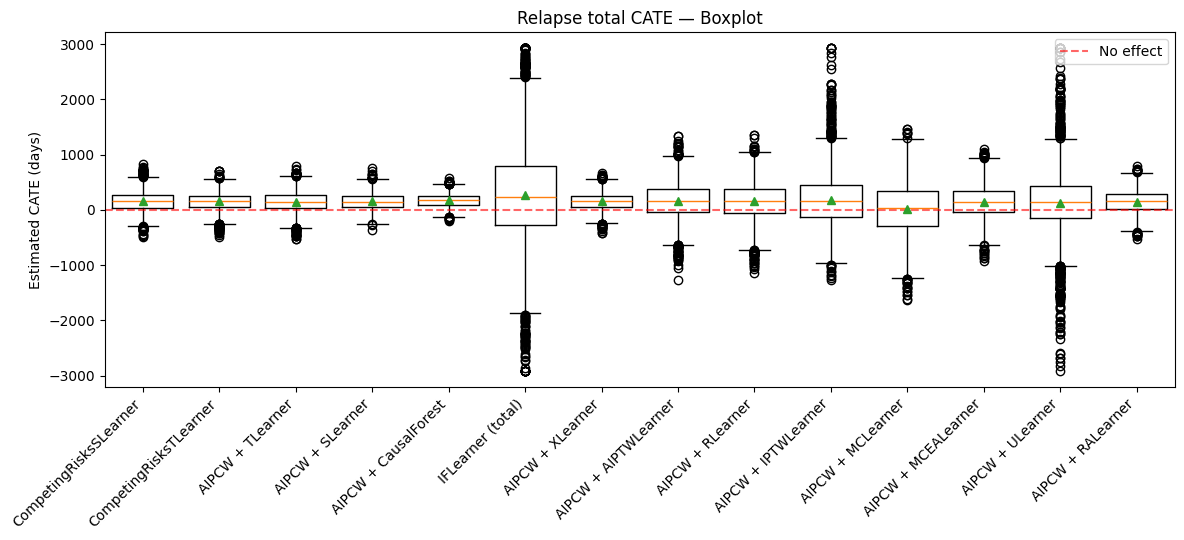

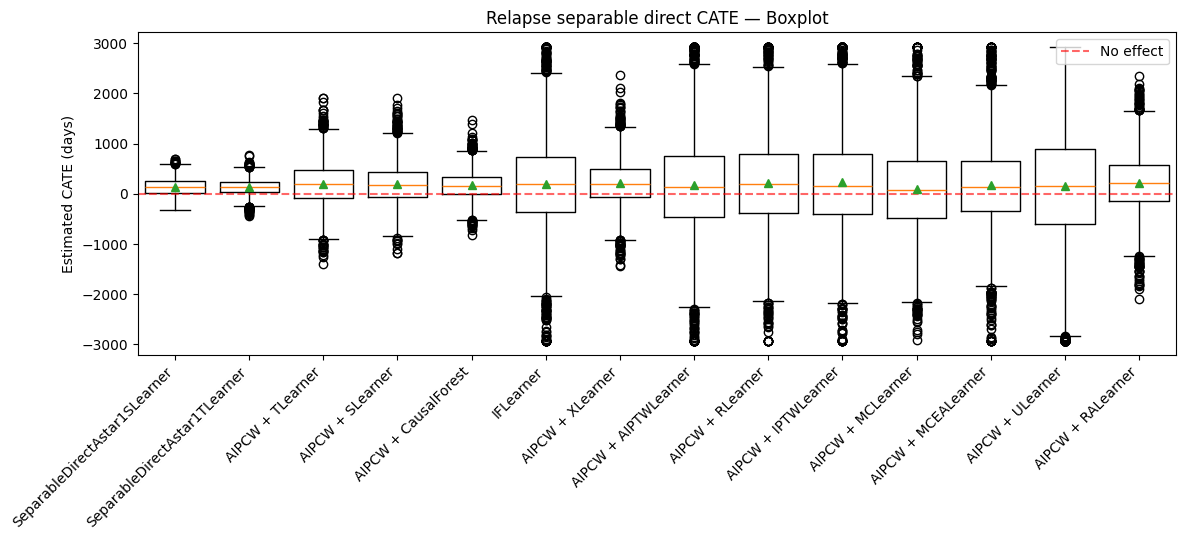

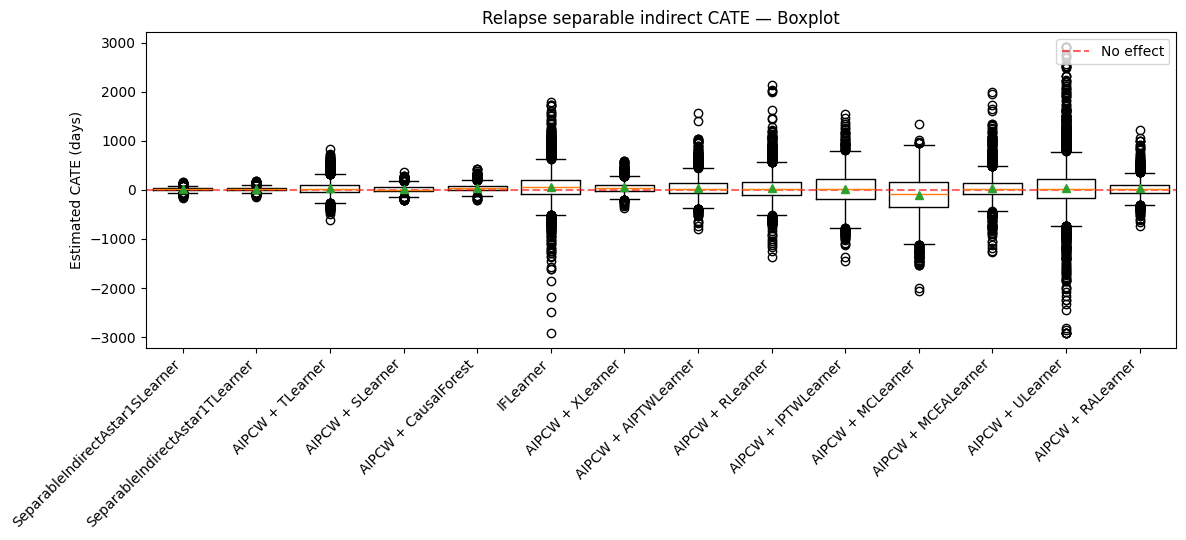

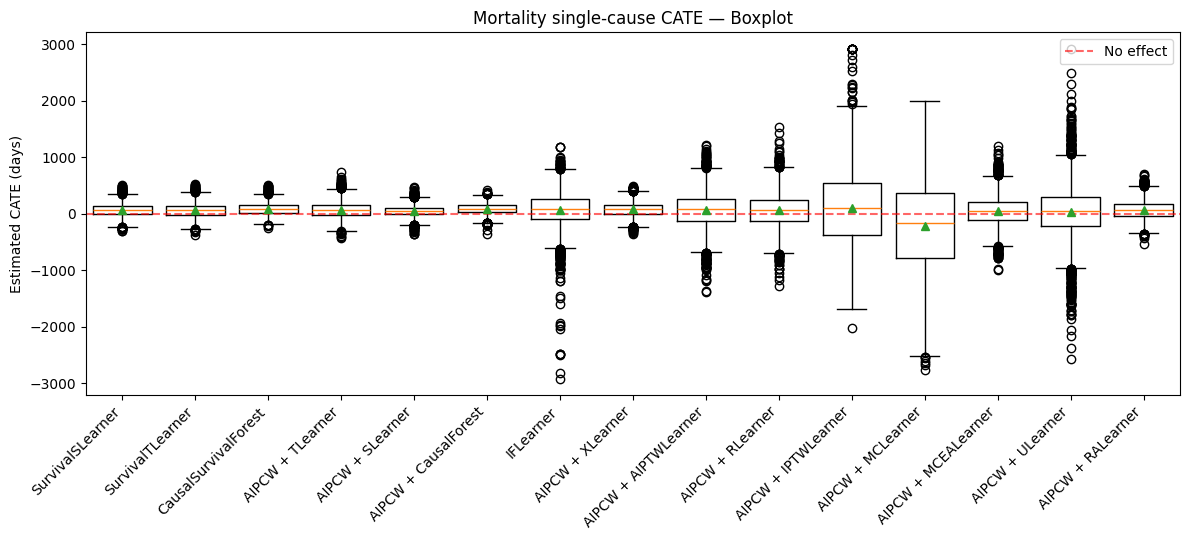

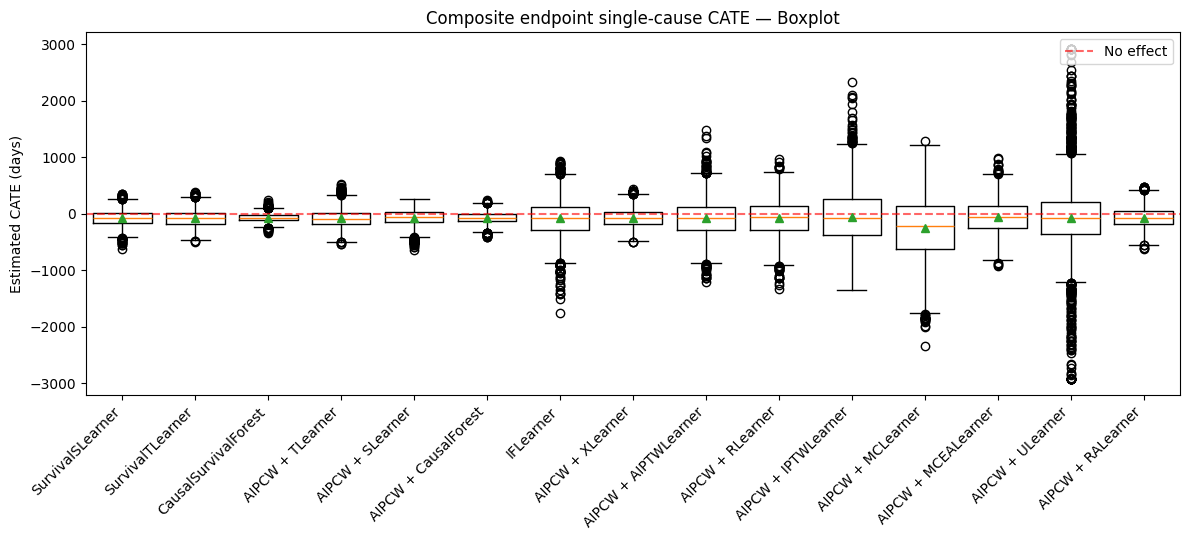

In [14]:
def plot_cate_boxplot(title, results_dict):
    learner_names = list(results_dict.keys())
    cate_arrays = [np.asarray(results_dict[name]).ravel() for name in learner_names]
    fig_width = max(12, 0.7 * len(learner_names))
    fig, ax = plt.subplots(figsize=(fig_width, 5.5))
    ax.boxplot(cate_arrays, showmeans=True, widths=0.8)
    ax.axhline(0, color='red', linestyle='--', alpha=0.6, label='No effect')
    ax.set_xticks(np.arange(1, len(learner_names) + 1))
    ax.set_xticklabels(learner_names, rotation=45, ha='right')
    ax.set_title(title)
    ax.set_ylabel('Estimated CATE (days)')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

for analysis_name, results_dict in analysis_results.items():
    plot_cate_boxplot(f"{analysis_name} — Boxplot", results_dict)


## Notes

### What is not reproduced here
- `relapse_cde_hte.R` (controlled direct effect / CDE) — this is a methodological variant
  requiring a different identification strategy and is not covered in the current Python implementation.

### Simplifications vs. the original R analyses
- **Nuisance/final models**: The original R analyses used `survSuperLearner` and `SuperLearner` ensembles. Here the notebook uses the package defaults: `RandomSurvivalForest` for censored nuisances and direct censored-outcome learners, `RandomForestClassifier` for binary nuisances, and `RandomForestRegressor` for continuous nuisances and pseudo-outcome final models.
- **Cross-fitting**: The original analyses used 2-fold cross-fitting (sample splitting). This notebook also uses 2-fold cross-fitting in the nuisance helpers and the learners imported from `econml.metalearners`.

### References
- Bejanyan N et al. (2021). *Myeloablative versus Reduced-Intensity Conditioning prior to
  Hematopoietic Cell Transplantation for Myeloid Malignancies*. Blood Advances.
- CIBMTR dataset: https://cibmtr.org/Manuscript/a020h00001F1sihAAB/P-5370